### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

varianza :  0.9009144549780872


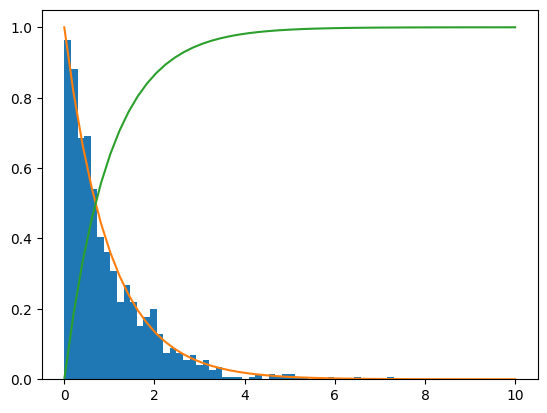

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

dist = sp.stats.gamma(a=1)
sample = dist.rvs(size=1000)
plt.hist(sample, bins=50, density = True)

lnsp = np.linspace(0, 10)
plt.plot(lnsp, dist.pdf(lnsp))

sp.stats.gamma.fit(sample)

cdf = dist.cdf(lnsp)
plt.plot(lnsp, cdf)
varianza = np.var(sample)
print("varianza : ", varianza)



### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

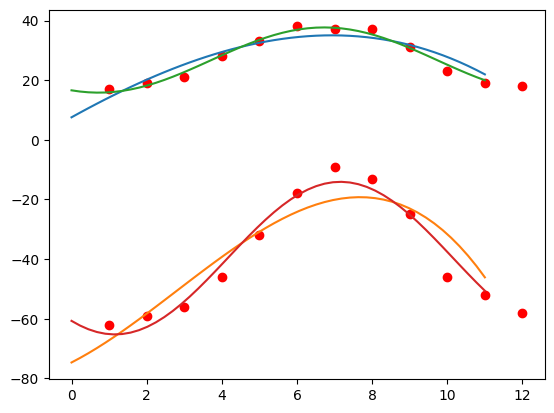

In [48]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
months = np.arange(1, 13)
import matplotlib.pyplot as plt

plt.plot(months, temp_max, "ro")
plt.plot(months, temp_min, "ro")
def polinomio_grado_3(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

params_max, *_ = sp.optimize.curve_fit(polinomio_grado_3, months, temp_max)
params_min, *_ = sp.optimize.curve_fit(polinomio_grado_3, months, temp_min)
x = np.linspace(0,11)
plt.plot(x, polinomio_grado_3(x, *params_max))
plt.plot(x, polinomio_grado_3(x, *params_min))

def sin(x,a,b,c):
    return c + a*np.sin((x+b)*2*np.pi/12)

params_max, *_ = sp.optimize.curve_fit(sin, months, temp_max)
params_min, *_ = sp.optimize.curve_fit(sin, months, temp_min)
x = np.linspace(0,11)
plt.plot(x, sin(x, *params_max))
plt.plot(x, sin(x, *params_min))

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

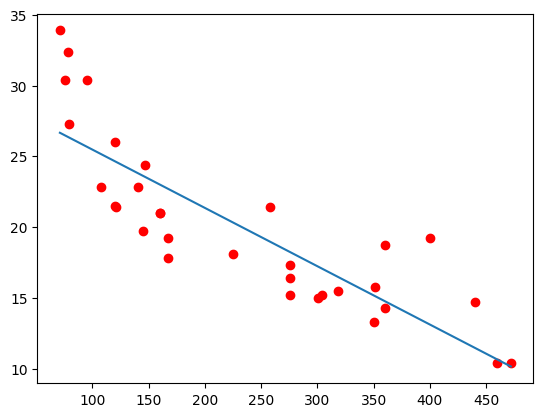

In [70]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df['mpg']


plt.plot(df['disp'].values, df['mpg'].values, "ro")
def lineare(x, a, b):
    return a*x + b
params, *_ = sp.optimize.curve_fit(lineare, df['disp'].values,  df['mpg'].values)
x = np.linspace(min(df['disp'].values),max(df['disp'].values))
plt.plot(x, lineare(x, *params))
# plt.plot(x, polinomio_grado_3(x, *params_min))

